# Módulo 3: Manejo de secuencias 2 (alineamientos).

## Objetivo 1: Programar algoritmos de tipo Dot-plot
Comenzaremos comparando secuencias utilizando el método gráfico de dot-plot, aprovechando conocimientos de la clase anterior y viendo de paso un poco de Numpy (librería de python para manejar matrices) y “algo” de gráficos.
Lo primero es levantar las dos secuencias (seq1 y seq2) luego convertirlas a formato “String”
Ahora lo que vamos a hacer es usar “numpy” para construir una matriz (el dot-plot) que tenga:
0=mismatch, 1=match

In [ ]:
#Veamos un poco còmo funciona numpy:
#Primero lo importamos como np
import numpy as np

filas=4
columnas = 5
mi_matriz=np.zeros((filas,columnas))

print (mi_matriz)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


### Ejercicio 1):
Cree una matriz de ceros (de dimensión de acuerdo a las longitudes de seq1 y se2) y luego recorramos todas las casillas poniendo 1 donde hay un match (consejo pruebe con una matriz más pequeña y luego vaya por la completa)

Analice la matriz obtenida (intente graficarla, para eso vea la nota)

In [ ]:
seq1 = "AATGCCACG"
seq2 = "TATGGCAGG"

def DotMatriz (seq1, seq2):
    filas = len(seq1)
    columnas = len(seq2)
    matriz = np.zeros((filas,columnas))
    x = []
    y = []
    for i in range (0,filas):
        for j in range (0,columnas):
            if seq1[i] == seq2[j]:
                matriz[i][j] = 1
                x.append(j)
                y.append(i)
    y=(np.array(y)-len(seq1))*-1
    return matriz,x,y

print (DotMatriz(seq1,seq2)[0])

[[0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 1. 1.]]


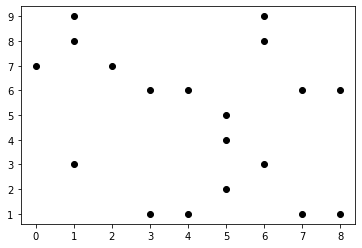

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

dotblot, x_lista, y_lista = (DotMatriz(seq1,seq2))

plt.plot(x_lista, y_lista, 'o', color='black')

In [ ]:
def FiltrarMatriz (matriz, wordlen, umbral):

    filas = len(matriz)
    columnas = len(matriz[0])
    new_matriz = np.zeros((filas,columnas))
    x = []
    y = []
    for i in range (0,filas-wordlen+1):
         for j in range (0,columnas-wordlen+1):
            test_umbral = 0
            if matriz[i][j] == 1:
                for k in range (0,wordlen):
                    if matriz[i+k][j+k] == 1:
                        test_umbral +=1
                if test_umbral >= umbral:
                    for k in range (0,wordlen):
                        if matriz[i+k][j+k] == 1:
                            new_matriz[i+k][j+k] = 1
                            y.append(i+k)
                            x.append(j+k)
    y=(np.array(y)-filas)*-1
    return new_matriz,x,y

([<matplotlib.axis.YTick at 0x7f3ce9847c50>,
 [Text(0, 0, 'G'),
  Text(0, 0, 'C'),
  Text(0, 0, 'A'),
  Text(0, 0, 'C'),
  Text(0, 0, 'C'),
  Text(0, 0, 'G'),
  Text(0, 0, 'T'),
  Text(0, 0, 'A'),
  Text(0, 0, 'A')])

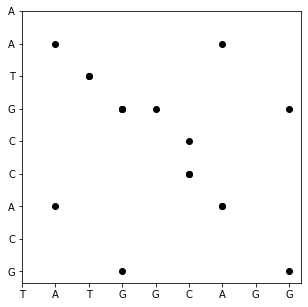

In [ ]:
dotblot_filtrado,x_lista2,y_lista2 = FiltrarMatriz(dotblot,3,2)

plt.figure(figsize=(5,5))
plt.plot(x_lista2, y_lista2, 'o', color='black')
plt.xticks(range(0,len(seq2)),list(seq2))

yticks = list(seq1)
#print (yticks)
yticks.reverse()
#print (yticks)

plt.yticks(range(1,len(seq1)+1),yticks)

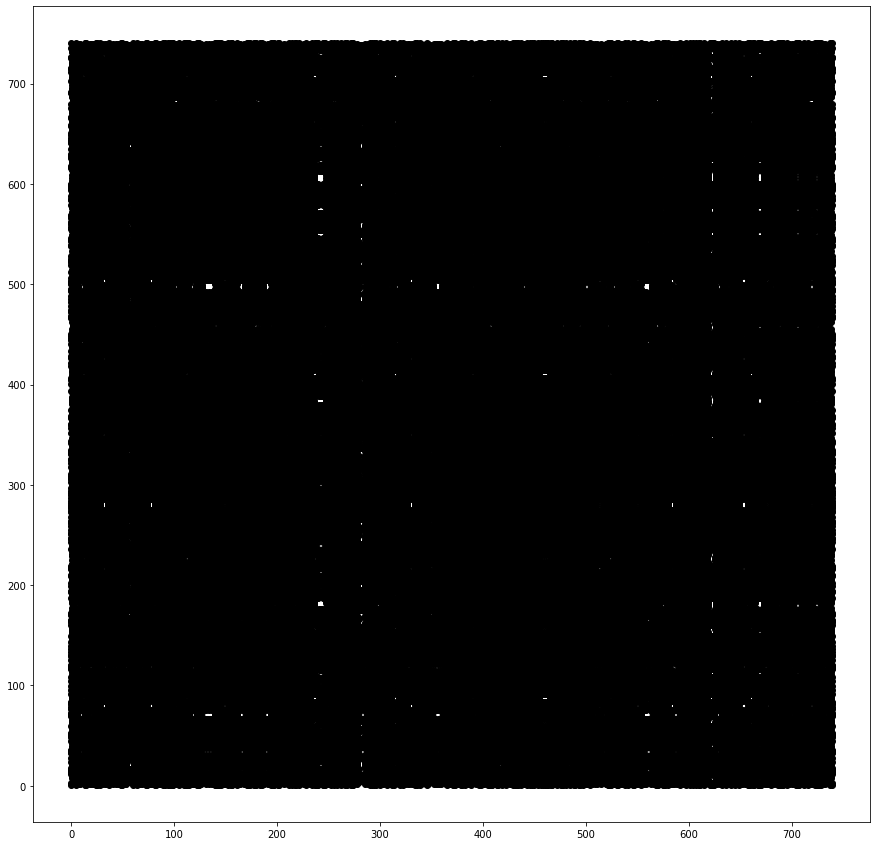

In [ ]:
!pip install biopython

from Bio import SeqIO

secuencia1 = SeqIO.read("seq1.fasta","fasta")
secuencia2 = SeqIO.read("seq2.fasta","fasta")

sec1 = str(secuencia1.seq)
sec2 = str(secuencia2.seq)

matrix_1 , x_lista, y_lista = DotMatriz (sec1, sec2)

plt.figure(figsize=(15,15))
plt.plot(x_lista, y_lista, 'o', color='black')

##Vemos que sin filtros, la matriz es ilegible

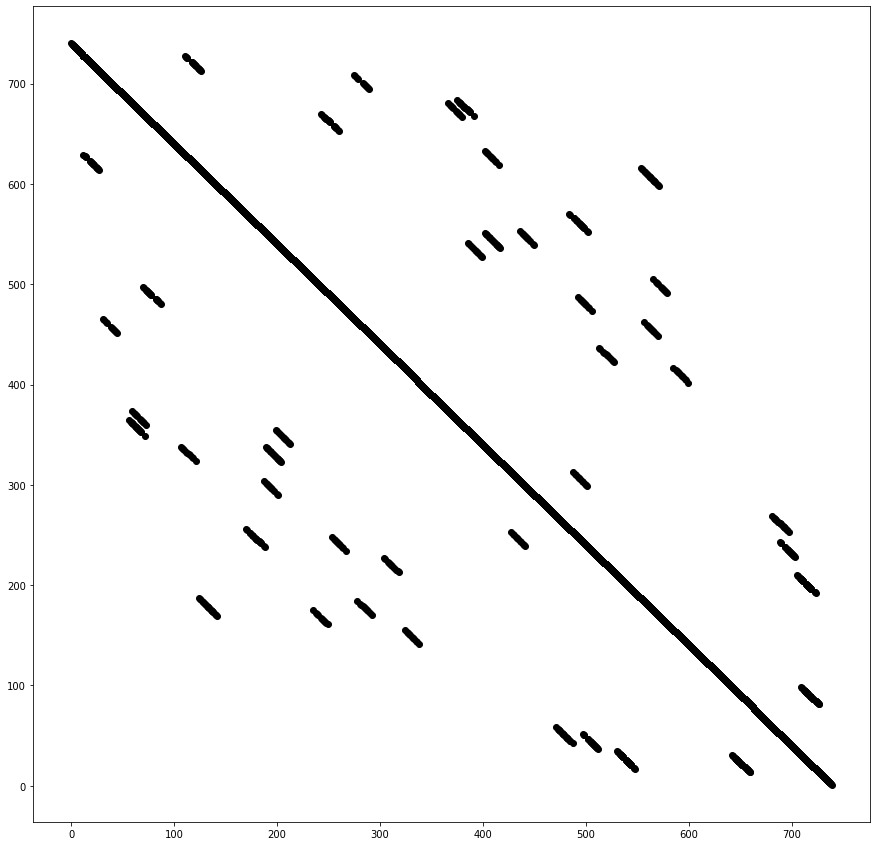

In [ ]:
##Realizamos un filtrado de ventana 15, permitiendo que al menos 11 de esas casillas sean "1"

matrix_2, x_lista2, y_lista2 = FiltrarMatriz(matrix_1,15,11)

plt.figure(figsize=(15,15))
plt.plot(x_lista2, y_lista2, 'o', color='black')

In [ ]:
###Módulo de alineamiento global por programación dinámica

seq1 = "GCATGCU"
seq2 = "GATTACA"

def RecorriendoMatriz (matriz_dir,seq1,seq2,i,j):
    if matriz_dir[i,j] == 0:
        return "","",0
    if matriz_dir[i,j] == 1:
        x, y,puntos = RecorriendoMatriz(matriz_dir,seq1,seq2,i-1,j-1)
        if seq1[i-1] == seq2[j-1]:
            puntos += 1
        return  x+seq1[i-1] , y+seq2[j-1],puntos
    if matriz_dir[i,j] == 2:
        x, y, puntos = RecorriendoMatriz(matriz_dir,seq1,seq2,i-1,j)
        return x+seq1[i-1] , y+"-",puntos
    if matriz_dir[i,j] == 3:
        x, y, puntos = RecorriendoMatriz(matriz_dir,seq1,seq2,i,j-1)
        return x+"-" , y+seq2[j-1],puntos

def Alineamiento (seq1,seq2,match,mismatch,gapopen,gapext):
    filas = len(seq1)
    columnas = len(seq2)
    #matriz_num es una matriz para los puntajes de alineación
    matriz_num = np.zeros((filas+1,columnas+1))
    #matriz_dir es una matriz que indica la dirección de alineamiento (1 -> diagonal, 2-> "desde arriba", 3->"desde la izq")
    matriz_dir = np.zeros((filas+1,columnas+1))

    for i in range(1,filas+1):
        matriz_num[i][0] = -gapopen - (i-1)*gapext
        matriz_dir[i][0] = 2

    for j in range(1,columnas+1):
        matriz_num[0][j] = -gapopen - (j-1)*gapext
        matriz_dir[0][j] = 3


    for i in range (0,filas):
        for j in range (0,columnas):
            if seq1[i] == seq2[j]:
                puntaje = match
            else:
                puntaje = -mismatch
            if matriz_dir[i][j+1] == 2:
                gap2 = gapext
            else:
                gap2 = gapopen
            if matriz_dir[i+1][j] == 3:
                gap3 = gapext
            else:
                gap3 = gapopen
            posibilidades=[matriz_num[i][j]+puntaje,matriz_num[i][j+1]-gap2,matriz_num[i+1][j]-gap3]
            matriz_num[i+1][j+1] = max(posibilidades)
            matriz_dir[i+1][j+1] = posibilidades.index(max(posibilidades))+1
    #print (matriz_num)
    #print (matriz_dir)
    return RecorriendoMatriz(matriz_dir,seq1,seq2,filas,columnas)

print (Alineamiento(seq1,seq2,1.,1.,1.,0.5))

#imprime seq1, seq2 y puntaje absoluto de identidad

('GCA-TGCU', 'G-ATTACA', 4)


Ahora para proteínas

([<matplotlib.axis.YTick at 0x7f3ce709f208>,
 [Text(0, 0, 'D'),
  Text(0, 0, 'C'),
  Text(0, 0, 'H'),
  Text(0, 0, 'G'),
  Text(0, 0, 'T'),
  Text(0, 0, 'A'),
  Text(0, 0, 'S'),
  Text(0, 0, 'S')])

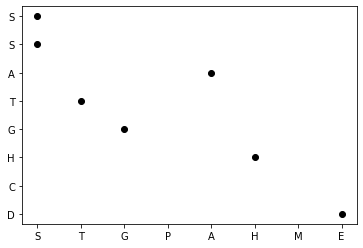

In [ ]:
from Bio.SubsMat.MatrixInfo import blosum62

prot1 = "SSATGHCD"
prot2 = "STGPAHME"

def DotMatrizProt (seq1, seq2, umbral):
    filas = len(seq1)
    columnas = len(seq2)
    matriz = np.zeros((filas,columnas))
    x = []
    y = []
    for i in range (0,filas):
        for j in range (0,columnas):
            if (seq1[i],seq2[j]) in blosum62.keys():
                valor = blosum62[(seq1[i],seq2[j])]
            else:
                valor = blosum62[(seq2[j],seq1[i])]

            if valor > umbral:
                matriz[i][j] = valor
                x.append(j)
                y.append(i)
    y=(np.array(y)-len(seq1))*-1
    return matriz,x,y

matriz_prot , xp_list , yp_list = DotMatrizProt(prot1,prot2,1)

plt.plot(xp_list, yp_list, 'o', color='black')
plt.xticks(range(0,len(prot2)),list(prot2))

yticks = list(prot1)
#print (yticks)
yticks.reverse()
#print (yticks)

plt.yticks(range(1,len(prot1)+1),yticks)

In [ ]:
prot1 = "SSATGHD"
prot2 = "SSAHCD"

def AlineamientoProt (seq1,seq2,penality):
    filas = len(seq1)
    columnas = len(seq2)
    matriz_num = np.zeros((filas+1,columnas+1))
    matriz_dir = np.zeros((filas+1,columnas+1))

    for i in range(1,filas+1):
        matriz_num[i][0] = i*-penality
    for j in range(1,columnas+1):
        matriz_num[0][j] = j*-penality

    for i in range (0,filas):
        for j in range (0,columnas):
            if (seq1[i],seq2[j]) in blosum62.keys():
                puntaje = blosum62[(seq1[i],seq2[j])]
            else:
                puntaje = blosum62[(seq2[j],seq1[i])]

            posibilidades=[matriz_num[i][j]+puntaje,matriz_num[i][j+1]-penality,matriz_num[i+1][j]-penality]
            matriz_num[i+1][j+1] = max(posibilidades)
            matriz_dir[i+1][j+1] = posibilidades.index(max(posibilidades))+1
    #print (matriz_num)
    #print (matriz_dir)
    return RecorriendoMatriz(matriz_dir,seq1,seq2,filas,columnas)

print (AlineamientoProt(prot1,prot2,1))

('SSATGH-D', 'SSA--HCD', 5)


In [ ]:
#dato de color para guardar en el caso de alineamiento de proteinas. como se hace con Byipython?
from Bio import pairwise2 #pairwise2.align.globalds busca el mejor alineamiento GLOBAL, para alineamientos locales se usa "aligner.mode = 'local', alignments = aligner.align(seq1, seq2)", sale de from Bio import Align
from Bio.SubsMat.MatrixInfo import blosum62 #se pueden importar distintas matrices de puntaje con este modulo, en este caso blosum62

alignments = pairwise2.align.globalds("LSSPADKTNVKKAA", "DDPEEKSAVNN", blosum62, -10, -0.5)
print(pairwise2.format_alignment(*alignments[0]))

# en el ejemplo, gap open penalty: 10 y gap extension penalty: 0.5
#pairwise2.align.globalds busca el mejor alineamiento GLOBAL, para alineamientos locales se usa "aligner.mode = 'local', alignments = aligner.align(seq1, seq2)"

## Objetivo 2: Parsear y analizar salida de BLAST
El algoritmo blast permite realizar búsquedas rápidas de secuencias sobre bases de datos (de secuencias). Esto lo hace mediante una heurística, la cual consiste en generar pequeñas secuencias semilla a partir de la consulta inicial, alinearlas contra cada una de las secuencias en la base de datos e ir extendiendo en medida que las correspondencias tengan un elevado score. Llamaremos query a la secuencia que se quiere buscar y db a la base sobre la cual se realiza dicha búsqueda.
BLAST en realidad son 4 algoritmos: blastn (query -> nu db -> nu), blastp (query -> prot db -> prot), blastx (query -> nucleótido , db -> prot )  y tblastn ( query -> prot, db -> nucl).
Los resultados son las correspondencias de la query con una entrada de la db, a la que llamaremos hit, métricas de esa correspondencia (identidad, cobertura, gaps) y dependiendo de lo solicitado, el alineamiento entre las mismas.

In [ ]:
#!blastp -query 'query_list.fasta' -db VFDB_setB_pro.fasta.fas -evalue 1e-5 -out multiblast.xml # query_list.fasta es el fasta de drra + el de ndk seguidos
!pip install biopython
from  Bio import SearchIO
from Bio import SeqIO
import pandas as pd


def blastres_tables(query_list):
    blastq_result = list(SearchIO.parse('multiblast.xml', 'blast-xml')) #leo los resultados de la búsqueda y los transformo en una lista
    querylist = list(SeqIO.parse(query_list, "fasta")) #lista de mis querys
    restable = [[[] for w in range(len(blastq_result[y]))] for y in range(len(blastq_result))] # lista que tiene tantas listas como querys y por cada query tantas listas como hits
    for z in range(len(querylist)): # itero para cada query
        if len(blastq_result[z]) == 0:
            print (querylist[z].id, "has no hits")
        for hit in range(len(blastq_result[z])): # itero a lo largo de todos los hits
            for hsp in range(len(blastq_result[z][hit])): # itero a lo largo de los HPS de cada hit
                restable[z][hit].append(blastq_result[z][hit].query_id) # en qué query estoy
                restable[z][hit].append(blastq_result[z][hit].id) # identidad de la proteína Hit
                restable[z][hit].append(blastq_result[z][hit][hsp].ident_num) # identidad
                restable[z][hit].append(blastq_result[z][hit][hsp].evalue)# signficancia (e-value) del alineamiento
                restable[z][hit].append(blastq_result[z][hit][hsp].query_range) # inicio y fin del alineamiento
                restable[z][hit].append(blastq_result[z][hit][hsp].aln_span) # longitud del alineamiento
                restable[z][hit].append(blastq_result[z][hit].description.rstrip("]").split("[")[-1]) #Especie
                #restable[z][hit].append(blastq_result[z][hit][0].hit.description)# especie de la proteina hit
    df = pd.concat([pd.DataFrame(d) for d in restable])
    return df

blastres_tables('query_list.fasta') #ejemplo con el archivo que contiene drra + ndk

sp|P68870|NDK_STAAU has no hits


,0,1,2,3,4,5,6
0,sp|Q29ST3|DRRA_LEGPN,VFG018236(gb|YP_096471),647,0.000000e+00,"(0, 647)",647,Legionella pneumophila subsp. pneumophila str....
1,sp|Q29ST3|DRRA_LEGPN,VFG041262(gb|YP_095134),36,4.953000e-10,"(512, 638)",129,Legionella pneumophila subsp. pneumophila str....
2,sp|Q29ST3|DRRA_LEGPN,VFG045589(gb|YP_096608),31,1.841360e-07,"(555, 636)",81,Legionella pneumophila subsp. pneumophila str....


## Objetivo 3: Programar generador de CONTIG

Cuando uno realiza experimentos de NGS uno de los pasos fundamentales suele ser el alineamiento de las lecturas para la obtención del contig correspondiente. En el archivo reads4contig.fastq hay una serie de lecturas en formato fasta. El objetivo es desarrollar un programa que permita alinearlos y armar el contig correspondiente. En una primera etapa vamos a suponer que las lecturas son perfectas (o sea no contienen errores de secuenciaciòn y/o variantes naturales).

Recordemos un poco los algoritmos de obtención de contigs. Lo que hacen estos algoritmos es primero comparar los reads entre sí, y a partir de los solapamientos generar un grafo que luego se recorre para generar la secuencia consenso.

En este caso sugerimos utilizar la siguiente estrategia (un poco màs simple, y similar a lo que se utiliza para obtener MSAs):
+ i) Comparar las lecturas todas contra todas,
+ ii) Buscar aquellas que “más” o “mejor” solapan
+ iii) => combinarlas generando una nueva lectura consenso
+ iv) iterar desde el punto i)


In [ ]:
##Hacer el contig
from Bio.Seq import Seq
#from Bio.Alphabet import IUPAC
from Bio import SeqIO

#Abro el archivo de fastqs
fastqs = SeqIO.parse("reads4contig.fastq","fastq")

#Aíslo la información sólo de secuencias y lo incluyo en una lista
fastas = []
for fastq in fastqs:
    fastas.append(fastq.seq)

def ArmarContig (fastas):
    #Si lallongitud de la lista = 1, entonces devolver el único valor
    print (len(fastas))
    if len(fastas) == 1:
        return fastas[0]
    #Voy a comparar la primer secuencia contra el resto
    query = fastas[0]
    aligns = []
    #Realizo los alineamientos del query contra las demás secuencias, fw y rev
    for fasta in fastas[1:]:
        aligns.append (Alineamiento (query,fasta,2.,1.,10.,1.))
        #print (fasta)
        rev = fasta.reverse_complement()
        aligns.append (Alineamiento (query,rev,2.,1.,10.,1.))
    #Aíslo los puntajes de cada alineamiento
    puntajes = []
    for align in aligns:
        puntajes.append(align[2])
    #Se condensará entonces el alineamiento de mayor puntaje
    high_align = aligns[puntajes.index(max(puntajes))]
    print (high_align)
    #En base a ese alineamiento, creo la secuencia consenso
    newseq = ""
    for i in range(0,len(high_align[0])):
        if high_align[0][i] == "-":
            newseq +=  high_align[1][i]
        else:
            newseq +=  high_align[0][i]

    #Elimino de la lista original la secuencia que obtuvo el mejor alineamiento
    lala = fastas.pop(puntajes.index(max(puntajes))//2+1)
    #y agrego la secuencia consenso
    fastas.append (Seq(newseq)) # IUPAC.unambiguous_dna))
    #Itera a la misma función con la lista de secuencias, sin la primera que se utilizó para alinear
    return (ArmarContig(fastas[1:]))



contig = (ArmarContig(fastas))

print (contig)

51
('TGAGCAGGTGAGTGTGTCTCAGGAAGGAAGTGCCTATTCATTATTACTTTTAAATGCAGAAATCTTAGTGCACACTCCTCACTGTAATGAACAGATTTTGA------', '------GGTGAGTGTGTCTCAGGAAGGAAGTGCCTATTCATTATTACTTTTAAATGCAGAAATCTTAGTGCACACTCCTCACTGTAATGAACAGATTTTGACGTTCT', 95)
50
('GTCTCAGGAAGGAAGTGCCTATTCATTATTACTTTTAAATGCAGAAATCTTAGTGCACACTCCTCACTGTAATGAACAGATTTTGACGTTCTCCTTCCCTT', 'GTCTCAGGAAGGAAGTGCCTATTCATTATTACTTTTAAATGCAGAAATCTTAGTGCACACTCCTCACTGTAATGAACAGATTTTGACGTTCTCCTTCCCTT', 101)
49
('GTCTCAGGAAGGAAGTGCCTATTCATTATTACTTTTAAATGCAGAAATCTTAGTGCACACTCCTCACTGTAATGAACAGATTTTGACGTTCTCCTTCCCTT', 'GTCTCAGGAAGGAAGTGCCTATTCATTATTACTTTTAAATGCAGAAATCTTAGTGCACACTCCTCACTGTAATGAACAGATTTTGACGTTCTCCTTCCCTT', 101)
48
('AAGGGAAGGAGAACGTCAAAATCTGTTCATTACAGTGAGGAGTGTGCAATAAGATTTCTGCATTTAAAAGTAATAATGAATAGGCACTTTCTTCCTGAGAC', 'AAGGGAAGGAGAACGTCAAAATCTGTTCATTACAGTGAGGAGTGTGCACTAAGATTTCTGCATTTAAAAGTAATAATGAATAGGCACTTCCTTCCTGAGAC', 99)
47
('-TCTCAGGAAGGAAGTGCCTATTCATTATTACTTTTAAATGCAGAAATCTTAGTGCACACTCCTCACTGTAATGAACAGATTTTGACGTTCTCCTTCCCTTT', 'GTC

#### Resultado: GAGAGGAGCACTTGTACTTAACTCTCTTGGTACTGGCAGGGTCAAGGTCATTGATTGTTACATCTATGTATTCATTTGAACTGCTTTTGGTTTAGTTTTGCAGAGCACTTTACAAATGTAAAAAAGGGAAGGAGAACGTCAAAATCTGTTCATTACAGTGAGGAGTGTGCACTAAGATTTCTGCATTTAAAAGTAATAATGAGTAGGCACTTCCTTCCTGAGACACACTCACCTGCCGG

Al hacer un blast da como resultado:

*Homo sapiens zinc finger MYND-type containing 11 (ZMYND11), RefSeqGene on chromosome 10*